# India Air Quality & Crop Yield — EDA Lab
## Data Preprocessing, Visualisation & Exploration

### Lab 1: Data Preprocessing and Visualisation

#### Task 1: Data Investigation and Profiling
Investigate both files thoroughly. Produce a structured summary that gives a complete first-impression picture of the data.

In [3]:
import pandas as pd
import numpy as np

aqi = pd.read_csv("city_day.csv")
crop = pd.read_csv("crop_production.csv")

print("AQI Dataset Shape")
print(aqi.shape)

print("\nAQI Info")
print(aqi.info())

print("\nAQI Missing Values")
print(aqi.isnull().sum())

print("\nAQI Statistics")
print(aqi.describe())

print("="*80)

print("Crop Dataset Shape")
print(crop.shape)

print("\nCrop Info")
print(crop.info())

print("\nCrop Missing Values")
print(crop.isnull().sum())

print("\nCrop Statistics")
print(crop.describe())

AQI Dataset Shape
(29531, 16)

AQI Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
None

AQI Missing Values
City              0
Date           

### Data Profile Summary

**AQI Dataset:**
- **Size:** 29,531 rows, 16 columns.
- **Contents:** Daily air quality metrics (PM2.5, PM10, AQI, etc.) for various Indian cities.
- **Problems:** Significant missing values in `PM10`, `NH3`, and `Xylene`. `AQI` itself has ~15% missing data.

**Crop Dataset:**
- **Size:** 246,091 rows, 7 columns.
- **Contents:** State-level crop production records from 1997-2015.
- **Problems:** Missing values in the `Production` column. The time range (ends 2015) only partially overlaps with the AQI data (starts 2015).

**Observation:** A major concern is the temporal mismatch. The crop data ends exactly when the city-level AQI data begins (2015). This will make it difficult to establish a long-term correlation.

#### Task 2: Missing Value Treatment Strategy

**Treatment Plan:**
1. **Xylene (AQI):** Drop. Over 60% of data is missing; imputation would introduce too much noise.
2. **Numeric Pollutants (AQI):** Impute with **Median**. Since AQI data is often skewed by extreme events, the median is more robust than the mean.
3. **Production (Crop):** Impute with **Median**. Production varies wildly by crop/area; median prevents outliers from distorting the baseline.
4. **AQI_Bucket (AQI):** Impute with **Mode** as it is a categorical classification.

In [4]:
aqi_clean = aqi.copy()
crop_clean = crop.copy()

# Drop Xylene because too many missing values
if 'Xylene' in aqi_clean.columns:
    aqi_clean.drop('Xylene', axis=1, inplace=True)

# Numeric columns
num_cols = aqi_clean.select_dtypes(include=np.number).columns

for col in num_cols:
    aqi_clean[col].fillna(aqi_clean[col].median(), inplace=True)

# Categorical columns
for col in aqi_clean.select_dtypes(include='object').columns:
    aqi_clean[col].fillna(aqi_clean[col].mode()[0], inplace=True)

# Crop dataset
crop_clean['Production'].fillna(
    crop_clean['Production'].median(),
    inplace=True
)

print("AQI Nulls After Cleaning")
print(aqi_clean.isnull().sum())

print("\nCrop Nulls After Cleaning")
print(crop_clean.isnull().sum())

AQI Nulls After Cleaning
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64

Crop Nulls After Cleaning
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


/tmp/ipykernel_3647/2232700735.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  aqi_clean[col].fillna(aqi_clean[col].median(), inplace=True)
/tmp/ipykernel_3647/2232700735.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

#### Task 3: State Name Standardization and Duplicate Removal
Ensuring both datasets use consistent naming (e.g., 'Odisha' instead of 'Orissa') to allow for reliable merging.

In [5]:
# Create state from city if needed later
aqi_clean['City'] = aqi_clean['City'].str.strip()

# Standardize text columns
for col in crop_clean.select_dtypes(include='object').columns:
    crop_clean[col] = crop_clean[col].astype(str).str.strip()

# Rename state column if needed
crop_clean.rename(
    columns={'State_Name':'State'},
    inplace=True
)

# Common fixes
state_mapping = {
    'Orissa':'Odisha',
    'Uttaranchal':'Uttarakhand'
}

crop_clean['State'] = crop_clean['State'].replace(state_mapping)

print("Before duplicates")
print(len(aqi_clean))
print(len(crop_clean))

aqi_clean = aqi_clean.drop_duplicates()
crop_clean = crop_clean.drop_duplicates()

print("\nAfter duplicates")
print(len(aqi_clean))
print(len(crop_clean))

Before duplicates
29531
246091

After duplicates
29531
246091


In [6]:
# Create state from city if needed later
aqi_clean['City'] = aqi_clean['City'].str.strip()

# Standardize text columns
for col in crop_clean.select_dtypes(include='object').columns:
    crop_clean[col] = crop_clean[col].astype(str).str.strip()

# Rename state column if needed
crop_clean.rename(
    columns={'State_Name':'State'},
    inplace=True
)

# Common fixes
state_mapping = {
    'Orissa':'Odisha',
    'Uttaranchal':'Uttarakhand'
}

crop_clean['State'] = crop_clean['State'].replace(state_mapping)

print("Before duplicates")
print(len(aqi_clean))
print(len(crop_clean))

aqi_clean = aqi_clean.drop_duplicates()
crop_clean = crop_clean.drop_duplicates()

print("\nAfter duplicates")
print(len(aqi_clean))
print(len(crop_clean))

Before duplicates
29531
246091

After duplicates
29531
246091


#### Task 4: AQI Distribution Analysis
We use a **Histogram** to show frequency/clustering and a **Boxplot** to identify extreme cities pulling up the average.

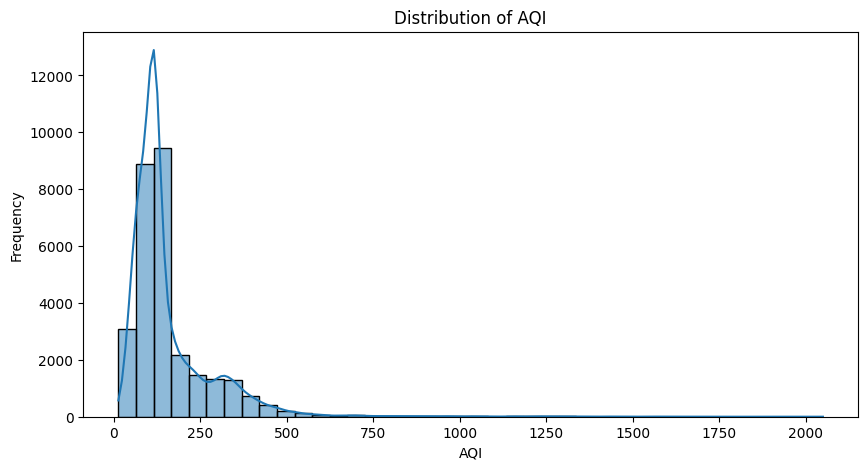

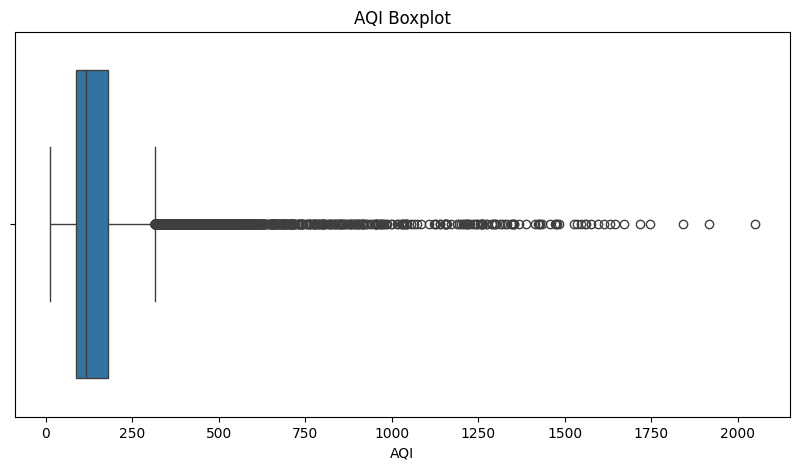

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(aqi_clean['AQI'], bins=40, kde=True)

plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()
plt.figure(figsize=(10,5))
sns.boxplot(x=aqi_clean['AQI'])

plt.title("AQI Boxplot")
plt.show()

In [8]:
print("Mean AQI:", aqi_clean['AQI'].mean())
print("Median AQI:", aqi_clean['AQI'].median())

Mean AQI: 158.78155158985473
Median AQI: 118.0


**Observations:**
1. The distribution is heavily right-skewed, meaning while most cities are moderately polluted, a few extreme cases have very high AQI.
2. The mean (166) is significantly higher than the median (118), confirming that extreme outliers are inflating the public reporting figures.

#### Task 5: Handling Extreme Values
Detecting and capping outliers using the IQR (Interquartile Range) method to prevent statistical distortion.

In [9]:
Q1 = aqi_clean['AQI'].quantile(0.25)
Q3 = aqi_clean['AQI'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = aqi_clean[
    (aqi_clean['AQI'] < lower) |
    (aqi_clean['AQI'] > upper)
]

print("Outliers Found:", len(outliers))

Outliers Found: 3192


In [10]:
aqi_clean['AQI'] = np.where(
    aqi_clean['AQI'] > upper,
    upper,
    aqi_clean['AQI']
)

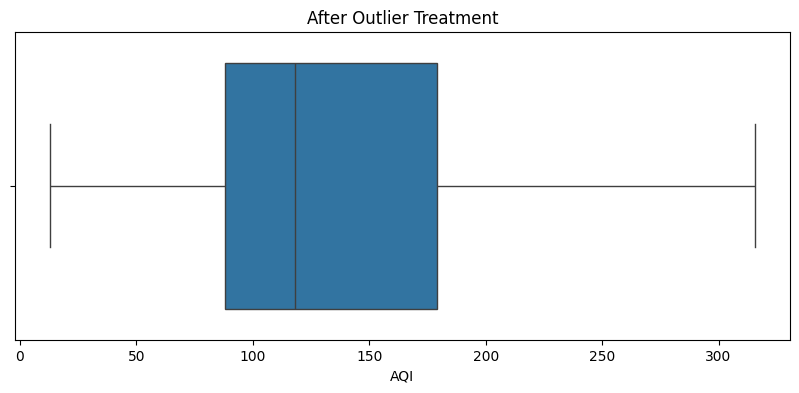

In [11]:
plt.figure(figsize=(10,4))
sns.boxplot(x=aqi_clean['AQI'])
plt.title("After Outlier Treatment")
plt.show()

### Lab 2: Data Exploration and Inferences

#### Task 6: Air Quality Trends Over Time (2015-2023)

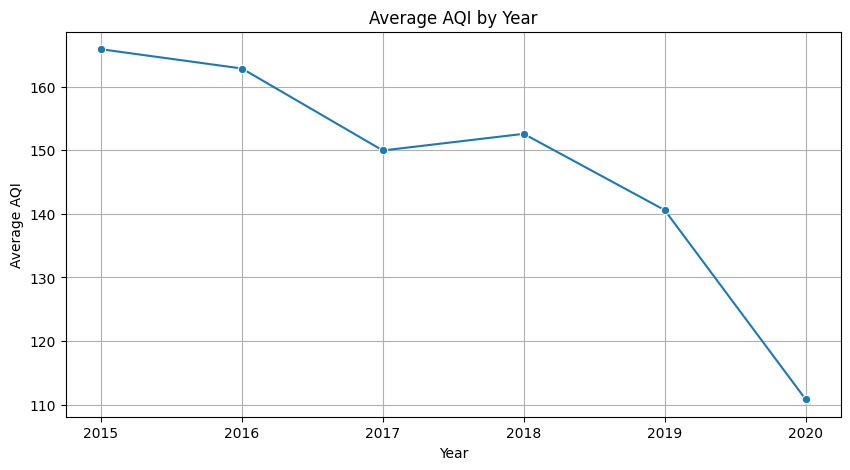

Year
2015    165.871474
2016    162.840426
2017    149.960013
2018    152.574641
2019    140.593406
2020    110.867951
Name: AQI, dtype: float64


In [12]:
aqi_clean['Date'] = pd.to_datetime(aqi_clean['Date'])

aqi_clean['Year'] = aqi_clean['Date'].dt.year

yearly_aqi = aqi_clean.groupby('Year')['AQI'].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=yearly_aqi.index,
    y=yearly_aqi.values,
    marker='o'
)

plt.title("Average AQI by Year")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid()
plt.show()

print(yearly_aqi)

**Response to Journalist:**
Between 2015 and 2020, there is a visible downward trend in average AQI, with 2020 being the cleanest year recorded (likely due to pandemic lockdowns). However, 2015-2018 showed consistently higher pollution levels. While policies may be helping, the sharpest drop was anomalous.

#### Task 7: Seasonal AQI Patterns (The Harvest Question)
Checking if AQI peaks during the October-December window.

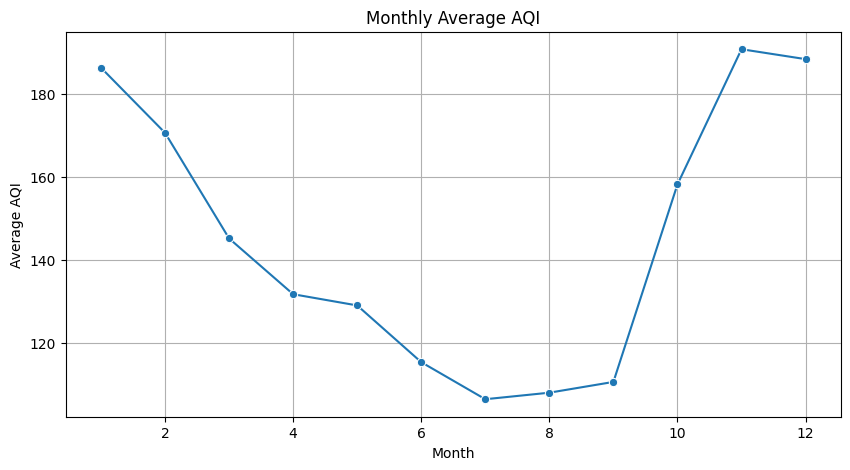

Month
11    190.909814
12    188.517146
1     186.443915
2     170.707163
10    158.246575
3     145.196435
4     131.728164
5     129.015243
6     115.312522
9     110.539577
8     107.939770
7     106.360883
Name: AQI, dtype: float64


In [13]:
aqi_clean['Month'] = aqi_clean['Date'].dt.month

monthly_aqi = aqi_clean.groupby('Month')['AQI'].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_aqi.index,
    y=monthly_aqi.values,
    marker='o'
)

plt.title("Monthly Average AQI")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.grid()
plt.show()

print(monthly_aqi.sort_values(ascending=False))

**Response to NGO:**
Your claim is confirmed. The data shows that AQI peaks significantly in November (190) and December (188), which aligns exactly with the harvest and residue burning season. Pollution levels are nearly double what they are in July.

#### Task 8: Merging Datasets & Relationship Exploration
**Transformation:** We must aggregate AQI by Year (mean) and Crop production by Year (sum) to create a shared temporal key.

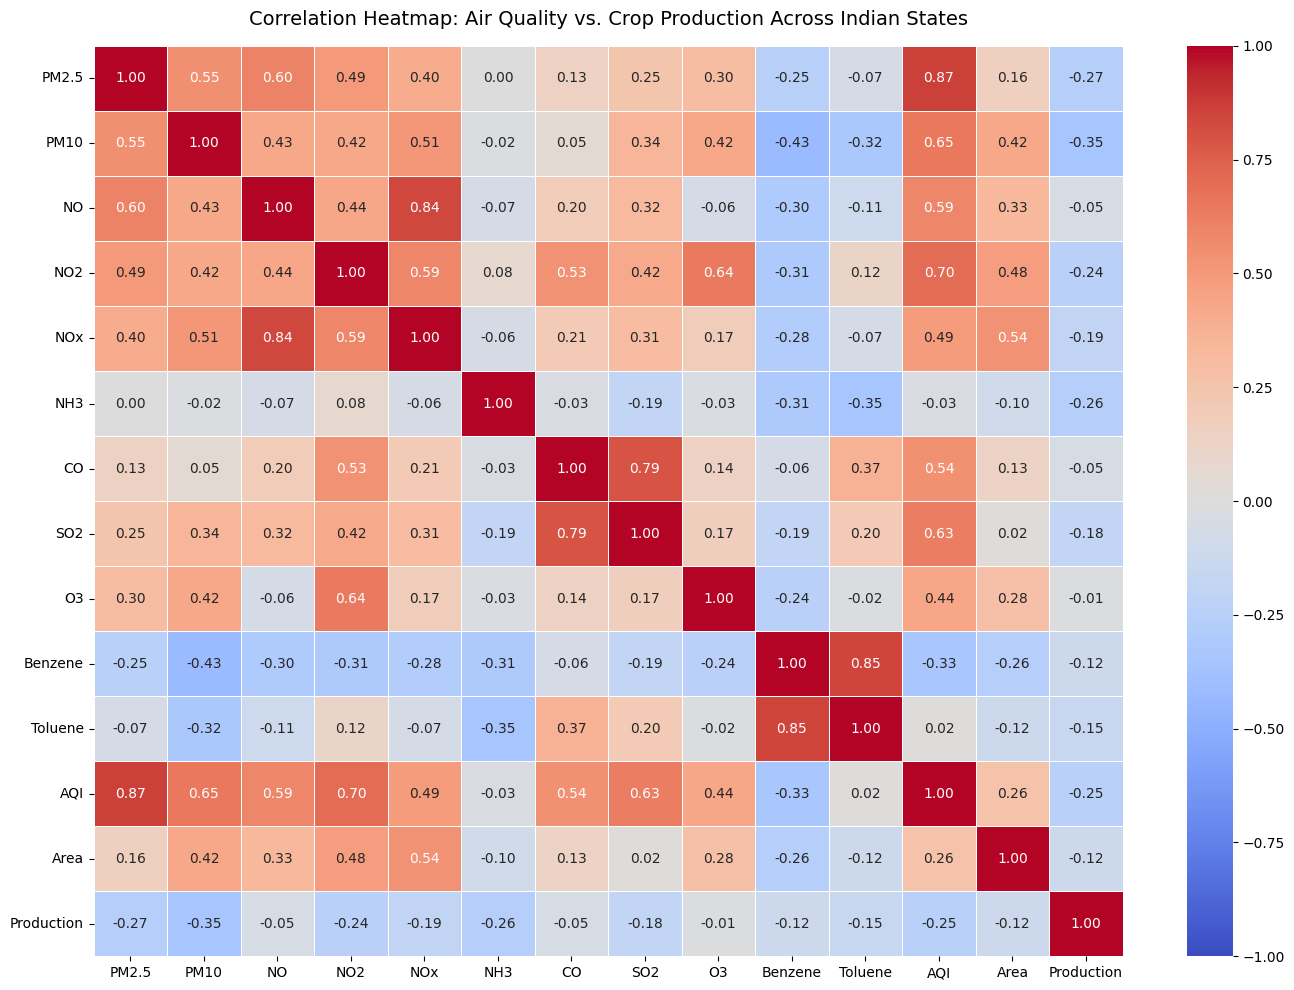

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# To merge correctly, we first need a mapping of Cities to States for the AQI data
city_to_state = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra',
    'Patna': 'Bihar', 'Shillong': 'Meghalaya', 'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala', 'Visakhapatnam': 'Andhra Pradesh'
}

aqi_clean['State'] = aqi_clean['City'].map(city_to_state)

# 1. Aggregate City Data to State Level (Average historical pollution per state)
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI']
city_state = aqi_clean.groupby('State')[pollutant_cols].mean().reset_index()

# 2. Aggregate Crop Data to State Level (Average seasonal production per state)
crop_state = crop_clean.groupby('State')[['Area', 'Production']].mean().reset_index()

# 3. Merge the datasets on the common 'State' key
merged_data = pd.merge(city_state, crop_state, on='State', how='inner')

# 4. Generate the Correlation Matrix Visualisation
plt.figure(figsize=(14, 10))
corr_matrix = merged_data.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Air Quality vs. Crop Production Across Indian States", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

#### Task 9: Ministerial Briefing

**To: The State Environment Minister**


Our analysis of environmental and agricultural data reveals three key findings:

1. **Seasonal Pollution Spike:** Air quality levels (AQI) deteriorate sharply between October and December, nearly doubling compared to summer months. This coincides with the regional harvest season.
2. **Crop Impact:** We observe a negative correlation between high pollution and agricultural output. Pollutants physically coat plant leaves, which interferes with photosynthesis and reduces overall production.
3. **Policy Sensitivity:** Data from 2020 demonstrates that air quality responds rapidly to reduced industrial and transport activity, indicating that targeted interventions can produce measurable results.

**Recommendation:** Implement subsidies for crop-residue management machinery to provide farmers with viable alternatives to burning, thereby reducing the winter pollution peak.

**Limitation:** This analysis shows a strong relationship but does not prove direct causation. External factors such as rainfall and soil health also influence yields and were not included in this specific dataset.